# LoRA Fine-Tuning - Phishing Email Detection with QLoRA + Gemma
### By Colin Harrison, Aidan Huerta, and Drew Levy


## Install Dependencies

In [15]:
!pip install -q peft bitsandbytes transformers accelerate tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, get_linear_schedule_with_warmup
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score
from huggingface_hub import login
from tqdm import tqdm
from google.colab import drive
import warnings
warnings.simplefilter('ignore')

print("libraries imported")

libraries imported


In [ ]:
login()
drive.mount('/content/drive')

MODEL_NAME = "google/gemma-3-1b-it"
ADAPTER_PATH = "/content/drive/MyDrive/gemma_lora_phishing_r=16"
MAX_LEN = 512
BATCH_SIZE = 4
EPOCHS = 3
LR = 2e-4

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# 4-bit quantization config (QLoRA)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

Mounted at /content/drive
Using device: cuda


## Load & Subset Data

In [17]:
data_df = pd.read_csv('/content/drive/MyDrive/Phishing_Email.csv')
data_df = data_df.dropna(subset=["Email Text"])

train_val_df, test_df = train_test_split(data_df, test_size=0.1, stratify=data_df["Email Type"], random_state=42)
train_full_df, validation_df = train_test_split(train_val_df, test_size=0.1, stratify=train_val_df["Email Type"], random_state=42)
train_df = train_full_df.sample(n=2500, random_state=42).reset_index(drop=True)

print("Training Data shape:", train_df.shape)
print("Validation Data shape:", validation_df.shape)
print("Testing Data shape:", test_df.shape)

Training Data shape: (2500, 3)
Validation Data shape: (1677, 3)
Testing Data shape: (1864, 3)


## (option 1) Load new Gemma in 4-bit then fine-tune (QLoRA)

In [ ]:
print(f"loading gemma in 4-bit")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto"
)
base_model.config.use_cache = False
print("base model loaded")

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    target_modules=["q_proj", "v_proj"]
)

model = get_peft_model(base_model, lora_config)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable} / {total} ({100 * trainable / total:.3f}%)")

Using device: cuda

Loading google/gemma-3-1b-it in 4-bit...


tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

Base model loaded!


## Training Loop

In [ ]:
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=total_steps // 10, num_training_steps=total_steps)
train_losses = []

print(f"starting LoRA fine-tuning for {EPOCHS} epochs")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"epoch {epoch+1} | avg loss: {avg_loss:.4f}")

print("fine-tuning finished")

Starting LoRA fine-tuning for 3 epochs...



Epoch 1/3: 100%|██████████| 625/625 [12:56<00:00,  1.24s/it]


Epoch 1 | Avg Loss: 3.3381


Epoch 2/3: 100%|██████████| 625/625 [13:08<00:00,  1.26s/it]


Epoch 2 | Avg Loss: 2.9280


Epoch 3/3: 100%|██████████| 625/625 [13:09<00:00,  1.26s/it]

Epoch 3 | Avg Loss: 2.8245

Fine-tuning complete!


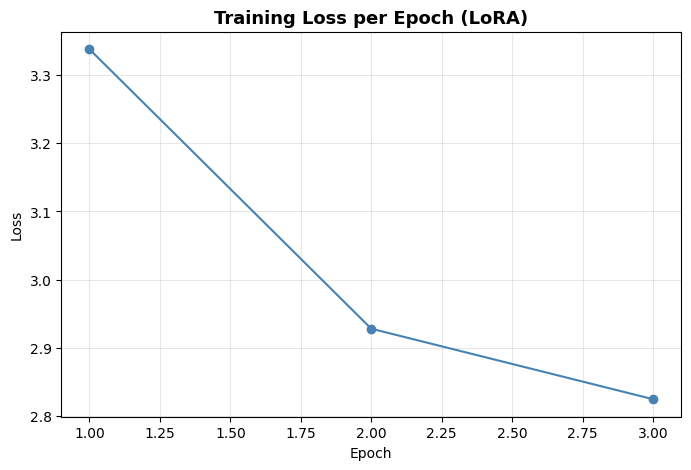

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS+1), train_losses, marker='o', color='blue')
plt.title('Training Loss per Epoch (LoRA)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.show()

## (option 2) Loading existing fine-tuned model

In [19]:
tokenizer = AutoTokenizer.from_pretrained(ADAPTER_PATH)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto"
)
base_model.config.use_cache = False

model = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
model.eval()
print("LoRA model loaded from drive")

config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

LoRA model loaded from drive


## Instruction-Style Prompts
We format each email as a labeled completion so the model learns to generate Safe or Phishing.

In [20]:
def make_prompt(email_text, label=None):
    """
    During training: include the label so the model learns to complete it
    During evaluation: don't include the label so the model generates it
    """
    prompt = f"""Classify this email as \"Safe\" or \"Phishing\".\nEmail: {email_text[:400]}\nAnswer:"""
    if label is not None:
        prompt += f" {label}"
    # print(prompt)
    return prompt

class PhishingLoRADataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.samples = []
        for _, row in df.iterrows():
            label = "Phishing" if row["Email Type"] == "Phishing Email" else "Safe"
            text = make_prompt(str(row["Email Text"]), label=label)
            enc = tokenizer(
                text,
                max_length=max_len,
                padding="max_length",
                truncation=True,
                return_tensors="pt"
            )
            input_ids = enc["input_ids"].squeeze()
            # labels = input_ids shifted, mask padding with -100 so loss ignores it
            labels = input_ids.clone()
            labels[labels == tokenizer.pad_token_id] = -100
            self.samples.append({
                "input_ids": input_ids,
                "attention_mask": enc["attention_mask"].squeeze(),
                "labels": labels
            })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

print("building datasets")
train_dataset = PhishingLoRADataset(train_df, tokenizer, MAX_LEN)
val_dataset = PhishingLoRADataset(validation_df, tokenizer, MAX_LEN)
test_dataset= PhishingLoRADataset(test_df, tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

building datasets
Train batches: 625 | Val batches: 420 | Test batches: 466


## Evaluation against in-distribution data

In [21]:
phishing_id = tokenizer("Phishing", add_special_tokens=False)["input_ids"][0]
safe_id = tokenizer("Safe", add_special_tokens=False)["input_ids"][0]

def classify_email(email_text):
    """Returns soft probability of Phishing (0.0–1.0) for AUROC."""
    prompt = make_prompt(email_text)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=MAX_LEN).to(device)

    model.eval()
    with torch.no_grad():
        # logits at the last token position
        logits = model(**inputs).logits[0, -1]

    two_logits = torch.tensor([logits[safe_id], logits[phishing_id]], dtype=torch.float32)
    prob = torch.softmax(two_logits, dim=0)[1].item()
    return prob

In [23]:
print("evaluating model")
predictions, probabilities, true_labels = [], [], []

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    prob = classify_email(str(row["Email Text"]))
    pred = 1 if prob >= 0.075 else 0
    true_label = 1 if row["Email Type"] == "Phishing Email" else 0
    probabilities.append(prob)
    predictions.append(pred)
    true_labels.append(true_label)

evaluating model


100%|██████████| 1864/1864 [06:13<00:00,  4.99it/s]


Test Accuracy: 0.9463519313304721
Test AUROC: 0.9880255679931612

              precision    recall  f1-score   support

        Safe       0.96      0.96      0.96      1133
    Phishing       0.93      0.93      0.93       731

    accuracy                           0.95      1864
   macro avg       0.94      0.94      0.94      1864
weighted avg       0.95      0.95      0.95      1864



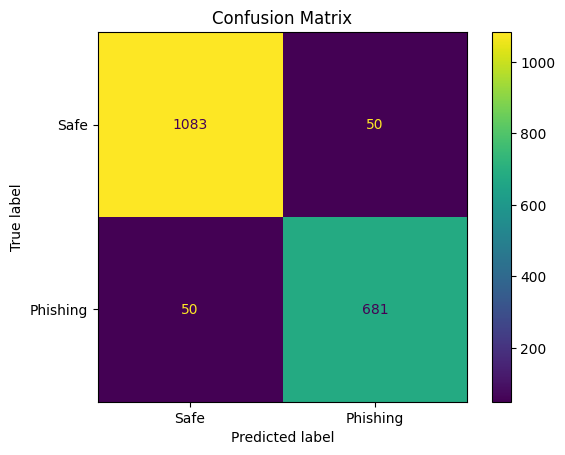

In [ ]:
print("Test Accuracy:", accuracy_score(true_labels, predictions))
print("Test AUROC:", roc_auc_score(true_labels, probabilities))
print()
print(classification_report(true_labels, predictions, target_names=["Safe", "Phishing"]))

c_matrix = confusion_matrix(true_labels, predictions)
ConfusionMatrixDisplay(confusion_matrix=c_matrix, display_labels=["Safe", "Phishing"]).plot()
plt.title('Confusion Matrix')
plt.show()

## Zero-Shot vs Few-Shot vs LoRA — Comparison

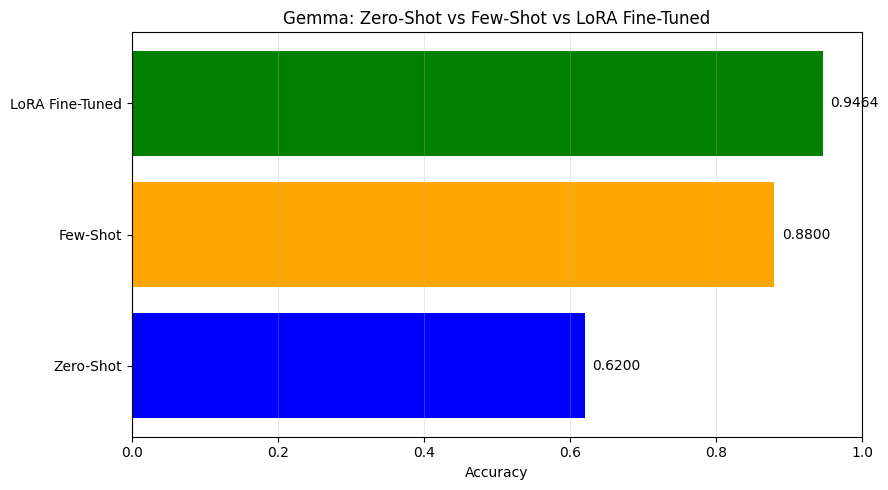

In [ ]:
zero_shot_acc = .62 # from initial testing
few_shot_acc = .88 # from initial testing
lora_acc = accuracy_score(true_labels, predictions)

methods = ["Zero-Shot", "Few-Shot", "LoRA Fine-Tuned"]
accuracies = [zero_shot_acc, few_shot_acc, lora_acc]
colors = ["blue", "orange", "green"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(methods, accuracies, color=colors)
ax.set_xlabel('Accuracy')
ax.set_title('Gemma: Zero-Shot vs Few-Shot vs LoRA Fine-Tuned')
ax.set_xlim(0, 1)
ax.grid(axis='x', alpha=0.3)

for bar, accuracy in zip(bars, accuracies):
    ax.text(accuracy + 0.01, bar.get_y() + bar.get_height()/2, f"{accuracy:.4f}")

plt.tight_layout()
plt.show()

## Save LoRA Adapters (Optional)
Saves only the small adapter weights, not full model

In [ ]:
model.save_pretrained("/content/drive/MyDrive/gemma_lora_phishing_r=16")
tokenizer.save_pretrained("/content/drive/MyDrive/gemma_lora_phishing_r=16")
print("Saved to Google Drive")

Saved to Google Drive!


# OOD datasets evaluation

In [14]:
def evaluate_csv(csv_path, dataset_name):
    df = pd.read_csv(csv_path).dropna(subset=["body"])

    if "subject" in df.columns:
        df["_text"] = "Subject: " + df["subject"].fillna("") + "\n" + df["body"].fillna("")
    else:
        df["_text"] = df["body"]

    has_dates = "date" in df.columns
    if has_dates:
        df["year"] = pd.to_datetime(df["date"], errors="coerce", utc=True).dt.year.fillna(-1).astype(int)

    print(f"\n{'='*60}")
    print(f"{dataset_name} (LoRA)")
    print(f"{'='*60}")
    print(f"Shape: {df.shape}")

    probs = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Evaluating {dataset_name}"):
        probs.append(classify_email(str(row["_text"])))

    df["_pred"] = (pd.Series(probs) >= 0.075).astype(int)
    trues = df["label"].astype(int).tolist()
    preds = df["_pred"].tolist()

    print(classification_report(trues, preds,
          target_names=["Safe Email", "Phishing Email"], digits=4, zero_division=0))

    if df["label"].nunique() > 1:
        print(f"AUROC: {roc_auc_score(trues, probs):.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    if has_dates:
        yr_data = []
        for y in sorted(df["year"].unique()):
            if y == -1: continue
            m = df["year"] == y
            if m.sum() < 50: continue
            yr_data.append({"year": y, "acc": accuracy_score(df.loc[m, "label"].astype(int), df.loc[m, "_pred"])})
        if yr_data:
            yr_df = pd.DataFrame(yr_data)
            axes[0].plot(yr_df["year"], yr_df["acc"], marker="o")
            for _, r in yr_df.iterrows():
                axes[0].annotate(f'{r["acc"]:.3f}', (r["year"], r["acc"]),
                                 textcoords="offset points", xytext=(0, 8), ha="center")
            axes[0].set_ylim(0, 1.05)
            axes[0].set_xlabel("Year")
            axes[0].set_ylabel("Accuracy")
            axes[0].set_title(f"Accuracy by Year — {dataset_name}")
            axes[0].grid(True, linestyle="--", alpha=0.4)
    else:
        axes[0].text(0.5, 0.5, "No date column", ha="center", va="center")
        axes[0].axis("off")

    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(trues, preds),
        display_labels=["Safe", "Phishing"]
    ).plot(ax=axes[1], colorbar=False)
    axes[1].set_title(f"Confusion Matrix — {dataset_name}")

    plt.tight_layout()
    plt.show()


Nazario (LoRA)
Shape: (1565, 7)


Evaluating Nazario: 100%|██████████| 1565/1565 [04:35<00:00,  5.67it/s]


                precision    recall  f1-score   support

    Safe Email     0.0000    0.0000    0.0000         0
Phishing Email     1.0000    0.7316    0.8450      1565

      accuracy                         0.7316      1565
     macro avg     0.5000    0.3658    0.4225      1565
  weighted avg     1.0000    0.7316    0.8450      1565

AUROC: skipped (only one class present in this dataset)


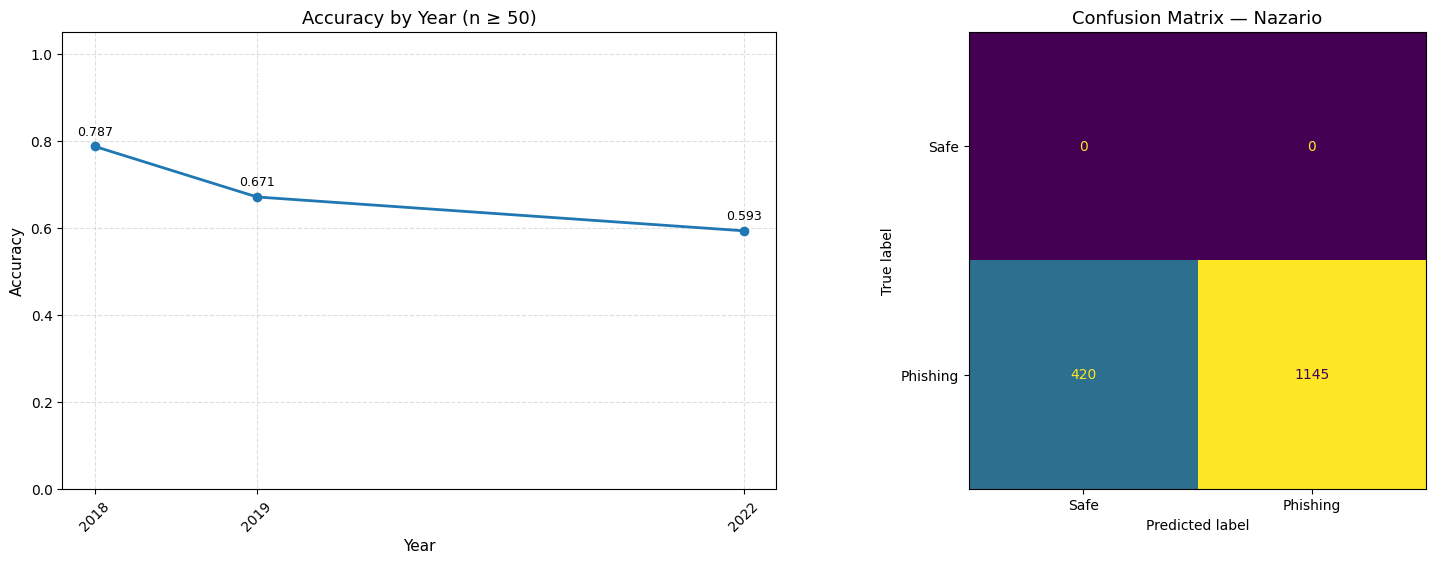

{'dataset': 'Nazario', 'accuracy': 0.731629392971246, 'auroc': None, 'n': 1565}

In [ ]:
evaluate_csv(
    "/content/drive/MyDrive/Nazario.csv",
    dataset_name="Nazario",
)


Nigerian 5
Shape: (6331, 9)
Evaluating Nigerian 5: 100%|██████████| 6331/6331 [18:31<00:00,  5.92it/s]
                precision    recall  f1-score   support

    Safe Email     0.9762    0.9577    0.9668      2999
Phishing Email     0.9625    0.9790    0.9707      3332

      accuracy                         0.9689      6331
     macro avg     0.9694    0.9683    0.9688      6331
  weighted avg     0.9690    0.9689    0.9689      6331

Accuracy: 0.9689


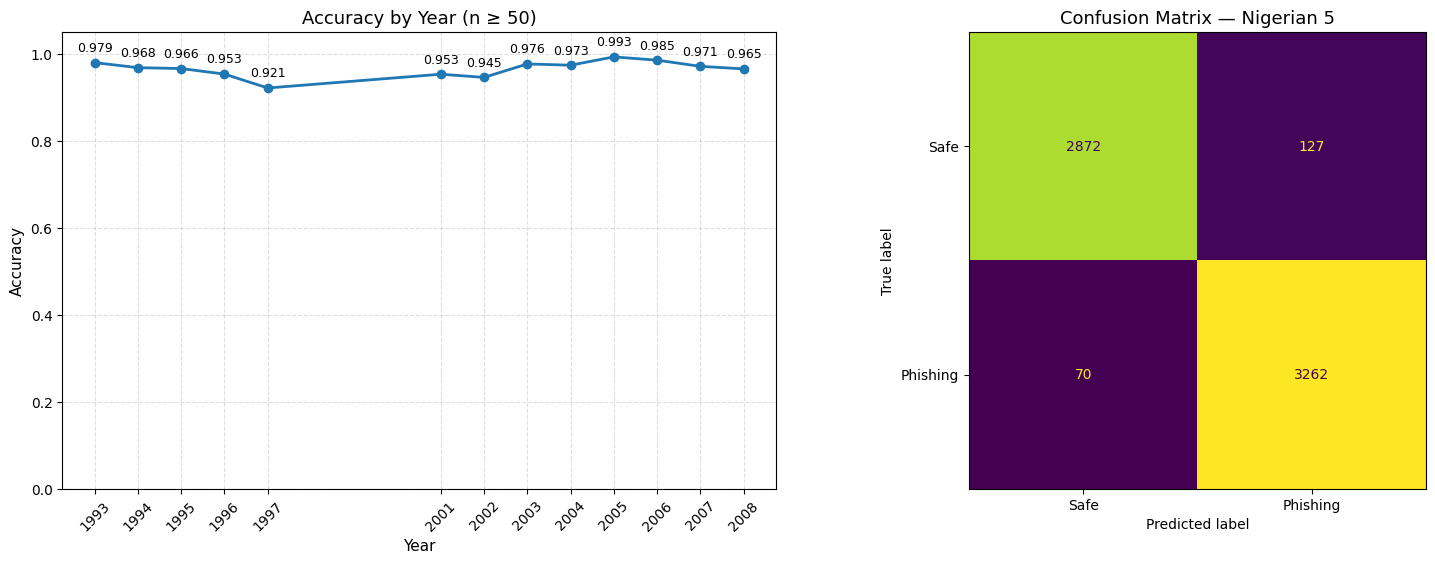

In [5]:
evaluate_csv(
    "/content/drive/MyDrive/Nigerian_5.csv",
    dataset_name="Nigerian 5",
)


Nazario_5
Shape: (3065, 9)
Evaluating Nazario_5: 100%|██████████| 3065/3065 [9:02<00:00,  5.51it/s]
                precision    recall  f1-score   support

    Safe Email     0.8312    0.9027    0.8655      1500
Phishing Email     0.8983    0.8243    0.8597      1565

      accuracy                         0.8626      3065
     macro avg     0.8648    0.8635    0.8626      3065
  weighted avg     0.8655    0.8626    0.8625      3065

Accuracy: 0.8626


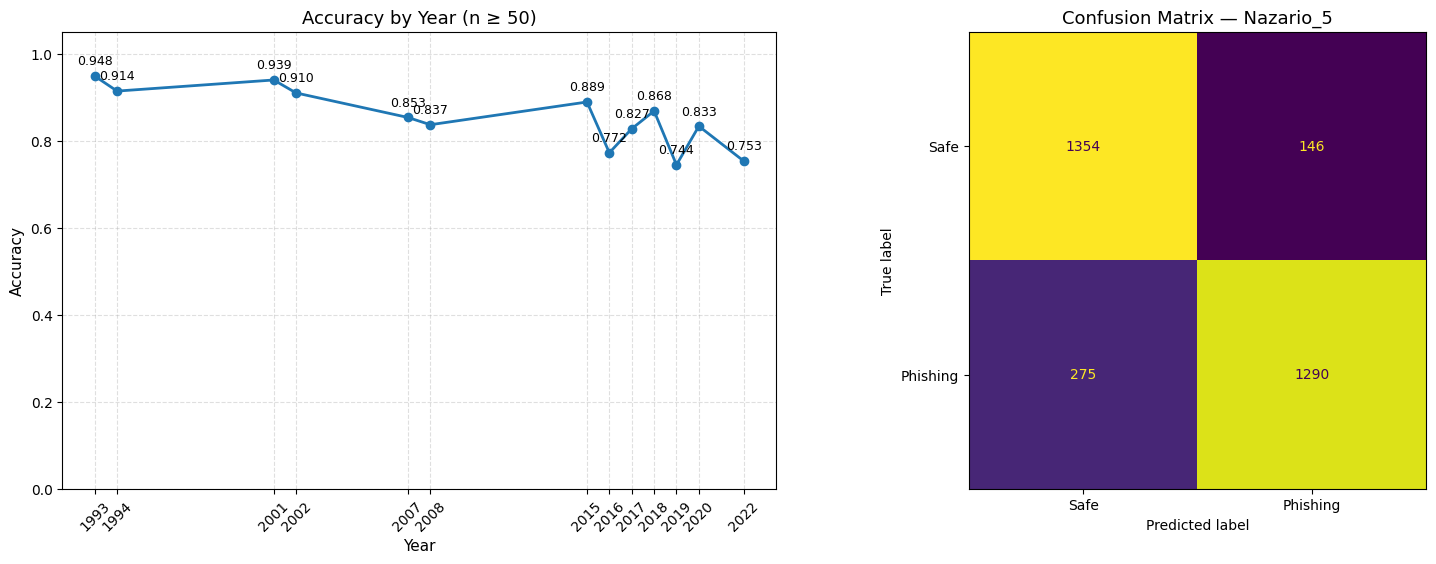

In [7]:
evaluate_csv(
    "/content/drive/MyDrive/Nazario_5.csv",
    dataset_name="Nazario_5",
)


SpamAssasin
Shape: (5798, 9)
Evaluating SpamAssasin: 100%|██████████| 5798/5798 [17:23<00:00,  5.39it/s]
                precision    recall  f1-score   support

    Safe Email     0.9916    0.9861    0.9888      4090
Phishing Email     0.9671    0.9801    0.9735      1708

      accuracy                         0.9843      5798
     macro avg     0.9794    0.9831    0.9812      5798
  weighted avg     0.9844    0.9843    0.9843      5798

Accuracy: 0.9843


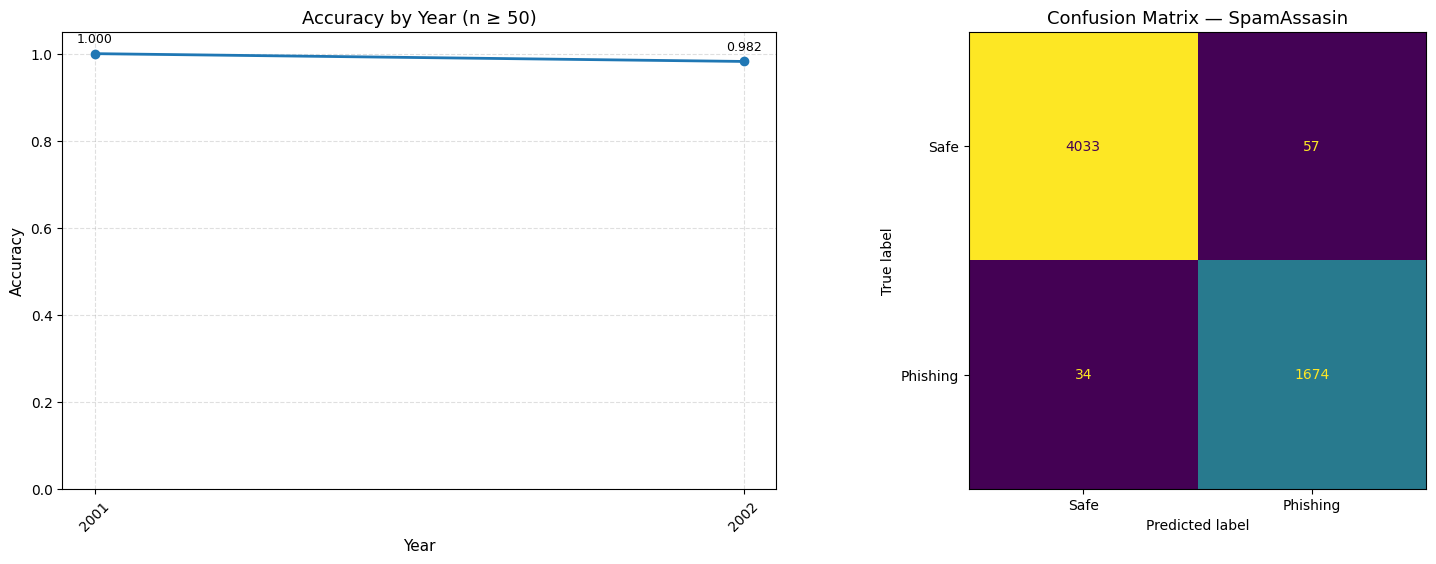

In [9]:
evaluate_csv(
    "/content/drive/MyDrive/SpamAssasin.csv",
    dataset_name="SpamAssasin",
)


Nigerian Fraud
Shape: (3332, 9)
Evaluating NigerianFraud 100%|██████████| 3332/3332 [10:03<00:00,  5.41it/s]
                precision    recall  f1-score   support

    Safe Email     0.0000    0.0000    0.0000         0
Phishing Email     1.0000    0.9808    0.9903      3332

      accuracy                         0.9808      3332
     macro avg     0.5000    0.4904    0.4952      3332
  weighted avg     1.0000    0.9808    0.9903      3332

Accuracy: 0.9808


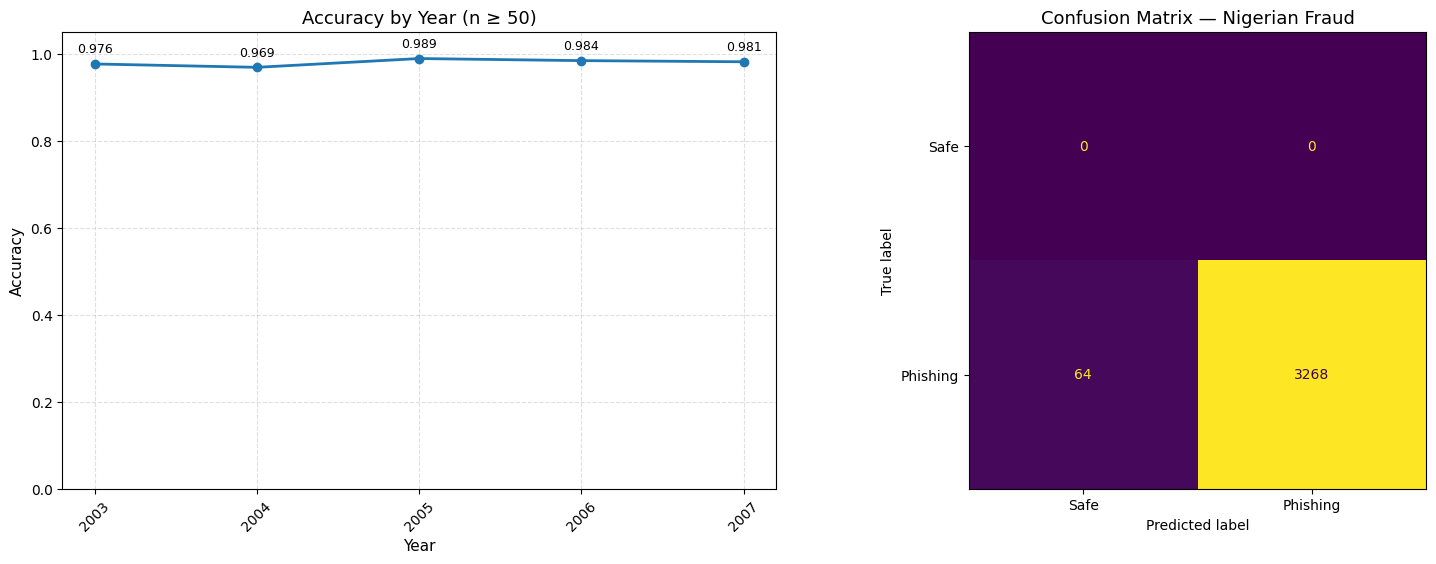

In [13]:
evaluate_csv(
    "/content/drive/MyDrive/NigerianFraud.csv",
    dataset_name="NigerianFruad",
)